# GridWorld MDP Demo: SARSA vs Q-learning

This notebook compares SARSA (on-policy TD control) and Q-learning (off-policy TD control) on a configurable GridWorld.

## How to run
1. Run all cells in order.
2. Edit the configuration cell to change map size (default is 5 x 5) and obstacle settings.
3. Re-run training and comparison cells after changing settings.
4. Use the printed metrics and plots to compare convergence behavior.


In [19]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np


## 1) Configuration

This cell controls experiment behavior.

- `GRID_ROWS`, `GRID_COLS`: world size (default 5 x 5).
- `ENABLE_RANDOM_OBSTACLES`: turn random obstacles on/off.
- `OBSTACLE_RATIO`: fraction of free cells converted to obstacles (excluding start and goal).
- Learning hyperparameters are shared between SARSA and Q-learning for fair comparison.


In [ ]:
# World size (default requested: 5 x 5)
GRID_ROWS = 10
GRID_COLS = 10

# Obstacle settings
ENABLE_RANDOM_OBSTACLES = True
OBSTACLE_RATIO = 0.15

# Training settings
EPISODES = 600
MAX_STEPS_PER_EPISODE = 200
ALPHA = 0.1
GAMMA = 0.95
EPSILON_START = 0.2
EPSILON_MIN = 0.02
EPSILON_DECAY = 0.995

# Reproducibility
SEED = 7


## 2) GridWorld environment

Environment rules:

- Start = top-left `(0, 0)`
- Goal = bottom-right `(rows-1, cols-1)`
- Actions = up, right, down, left
- Moving into a wall or obstacle leaves the agent in the same state
- Reward = `-1` per step, `+10` at goal

Obstacle generation is random but never places obstacles on start or goal.


In [21]:
State = Tuple[int, int]
QTable = Dict[State, np.ndarray]


@dataclass(frozen=True)
class GridWorld:
    """Rectangular GridWorld with optional random obstacle generation."""

    rows: int
    cols: int
    random_obstacles: bool = False
    obstacle_ratio: float = 0.0
    seed: int = 0

    def __post_init__(self) -> None:
        if self.rows <= 1 or self.cols <= 1:
            raise ValueError("rows and cols must be greater than 1")
        if not 0.0 <= self.obstacle_ratio < 1.0:
            raise ValueError("obstacle_ratio must be in [0.0, 1.0)")

        object.__setattr__(self, "start", (0, 0))
        object.__setattr__(self, "goal", (self.rows - 1, self.cols - 1))
        object.__setattr__(self, "actions", ["up", "right", "down", "left"])
        object.__setattr__(
            self,
            "action_delta",
            {
                "up": (-1, 0),
                "right": (0, 1),
                "down": (1, 0),
                "left": (0, -1),
            },
        )
        object.__setattr__(self, "rng", np.random.default_rng(self.seed))
        object.__setattr__(self, "obstacles", self._generate_obstacles())

    def _generate_obstacles(self) -> set[State]:
        """Sample random obstacles while preserving start and goal cells."""
        if not self.random_obstacles or self.obstacle_ratio <= 0.0:
            return set()

        candidates = [
            (r, c)
            for r in range(self.rows)
            for c in range(self.cols)
            if (r, c) not in {self.start, self.goal}
        ]
        count = int(len(candidates) * self.obstacle_ratio)
        if count <= 0:
            return set()

        picks = self.rng.choice(len(candidates), size=count, replace=False)
        return {candidates[int(i)] for i in np.atleast_1d(picks)}

    def reset(self) -> State:
        """Return the start state for a new episode."""
        return self.start

    def step(self, state: State, action: str) -> Tuple[State, float, bool]:
        """Apply an action and return (next_state, reward, done)."""
        dr, dc = self.action_delta[action]
        nr, nc = state[0] + dr, state[1] + dc

        in_bounds = 0 <= nr < self.rows and 0 <= nc < self.cols
        blocked = (not in_bounds) or ((nr, nc) in self.obstacles)
        next_state = state if blocked else (nr, nc)

        if next_state == self.goal:
            return next_state, 10.0, True
        return next_state, -1.0, False

    def states(self) -> List[State]:
        """Return all states excluding obstacle cells."""
        return [
            (r, c)
            for r in range(self.rows)
            for c in range(self.cols)
            if (r, c) not in self.obstacles
        ]


def initialize_q_table(env: GridWorld) -> QTable:
    """Initialize tabular Q-values to zero for every valid state."""
    return {
        state: np.zeros(len(env.actions), dtype=float)
        for state in env.states()
    }


def epsilon_greedy_action(
    q_table: QTable,
    state: State,
    epsilon: float,
    rng: np.random.Generator,
) -> int:
    """Sample an action index using epsilon-greedy policy."""
    if rng.random() < epsilon:
        return int(rng.integers(0, len(q_table[state])))
    return int(np.argmax(q_table[state]))


## 3) SARSA and Q-learning implementations

Both agents use epsilon-greedy behavior.

- SARSA update uses `Q(next_state, next_action)` (on-policy)
- Q-learning update uses `max_a Q(next_state, a)` (off-policy)

This setup isolates the algorithmic difference while keeping all other factors equal.


In [22]:
def train_sarsa(env: GridWorld) -> Tuple[QTable, List[float], List[int]]:
    """Train SARSA and return (q_table, episode_rewards, episode_steps)."""
    rng = np.random.default_rng(SEED)
    q_table = initialize_q_table(env)
    rewards: List[float] = []
    steps: List[int] = []

    epsilon = EPSILON_START
    for _ in range(EPISODES):
        state = env.reset()
        action_idx = epsilon_greedy_action(q_table, state, epsilon, rng)
        episode_reward = 0.0

        for step in range(1, MAX_STEPS_PER_EPISODE + 1):
            action = env.actions[action_idx]
            next_state, reward, done = env.step(state, action)
            episode_reward += reward

            next_action_idx = epsilon_greedy_action(
                q_table, next_state, epsilon, rng
            )
            td_target = reward + (
                0.0 if done else GAMMA * q_table[next_state][next_action_idx]
            )
            q_table[state][action_idx] += ALPHA * (
                td_target - q_table[state][action_idx]
            )

            state, action_idx = next_state, next_action_idx
            if done:
                break

        rewards.append(episode_reward)
        steps.append(step)
        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    return q_table, rewards, steps


def train_q_learning(env: GridWorld) -> Tuple[QTable, List[float], List[int]]:
    """Train Q-learning and return (q_table, episode_rewards, episode_steps)."""
    rng = np.random.default_rng(SEED)
    q_table = initialize_q_table(env)
    rewards: List[float] = []
    steps: List[int] = []

    epsilon = EPSILON_START
    for _ in range(EPISODES):
        state = env.reset()
        episode_reward = 0.0

        for step in range(1, MAX_STEPS_PER_EPISODE + 1):
            action_idx = epsilon_greedy_action(q_table, state, epsilon, rng)
            action = env.actions[action_idx]
            next_state, reward, done = env.step(state, action)
            episode_reward += reward

            td_target = reward + (
                0.0 if done else GAMMA * float(np.max(q_table[next_state]))
            )
            q_table[state][action_idx] += ALPHA * (
                td_target - q_table[state][action_idx]
            )

            state = next_state
            if done:
                break

        rewards.append(episode_reward)
        steps.append(step)
        epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    return q_table, rewards, steps


## 4) Train both agents on the same map

This cell creates one environment and trains both algorithms against identical obstacle layout and hyperparameters.


In [23]:
env = GridWorld(
    rows=GRID_ROWS,
    cols=GRID_COLS,
    random_obstacles=ENABLE_RANDOM_OBSTACLES,
    obstacle_ratio=OBSTACLE_RATIO,
    seed=SEED,
)

print(f"Grid size: {env.rows} x {env.cols}")
print(f"Start: {env.start}, Goal: {env.goal}")
print(f"Obstacle count: {len(env.obstacles)}")
print(f"Obstacle locations: {sorted(env.obstacles)}")

sarsa_q, sarsa_rewards, sarsa_steps = train_sarsa(env)
qlearn_q, qlearn_rewards, qlearn_steps = train_q_learning(env)


Grid size: 10 x 10
Start: (0, 0), Goal: (9, 9)
Obstacle count: 14
Obstacle locations: [(0, 1), (0, 6), (2, 1), (2, 8), (2, 9), (5, 2), (5, 4), (6, 0), (7, 0), (7, 6), (7, 9), (8, 1), (8, 4), (8, 9)]


## 5) Compare metrics and learned greedy policies

What to examine:

1. Episode reward trend (higher is better).
2. Steps per episode (lower is better).
3. Final greedy policy maps for each algorithm.


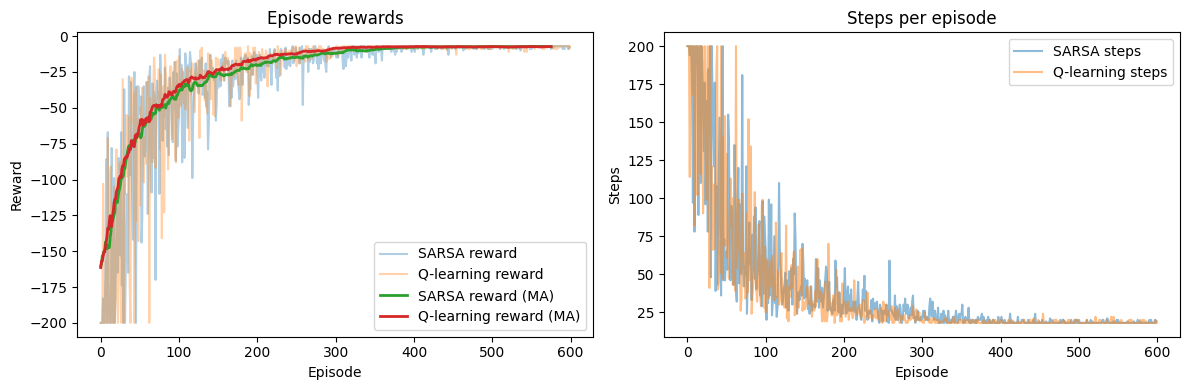

Final 50-episode mean reward
SARSA:      -7.28
Q-learning: -7.34

Final 50-episode mean steps
SARSA:      18.28
Q-learning: 18.34

Greedy policy (SARSA)
S # < v v > # < < <
> > > v v v v v ^ >
v # > v > > v v # #
> > > v v > v v v <
> > > > > > v v v <
> v # > # > > > v <
# > > > v v > v v <
# > > > > v # > v #
< # v v # > > > v #
^ v > > > > > > > G

Greedy policy (Q-learning)
S # v v v < # ^ ^ >
> > > > v v v v v >
v # > > > v v v # #
> > > > > v v v v >
> > > > > > > v v >
> v # < # > > v v <
# v ^ > > > > > v <
# > v v > v # > v #
^ # > v # v v > v #
< ^ > > > > > > > G


In [24]:
def moving_average(values: List[float], window: int = 25) -> np.ndarray:
    """Compute moving average for smoother training curves."""
    arr = np.asarray(values, dtype=float)
    if arr.size < window:
        return arr
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(arr, kernel, mode="valid")


def policy_grid(env: GridWorld, q_table: QTable) -> List[str]:
    """Render greedy policy as text arrows over the grid."""
    arrow = {"up": "^", "right": ">", "down": "v", "left": "<"}
    rows: List[str] = []
    for r in range(env.rows):
        row: List[str] = []
        for c in range(env.cols):
            s = (r, c)
            if s == env.start:
                row.append("S")
            elif s == env.goal:
                row.append("G")
            elif s in env.obstacles:
                row.append("#")
            else:
                best = int(np.argmax(q_table[s]))
                row.append(arrow[env.actions[best]])
        rows.append(" ".join(row))
    return rows

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sarsa_rewards, alpha=0.35, label="SARSA reward")
axes[0].plot(qlearn_rewards, alpha=0.35, label="Q-learning reward")
axes[0].plot(moving_average(sarsa_rewards), linewidth=2, label="SARSA reward (MA)")
axes[0].plot(moving_average(qlearn_rewards), linewidth=2, label="Q-learning reward (MA)")
axes[0].set_title("Episode rewards")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].legend()

axes[1].plot(sarsa_steps, alpha=0.5, label="SARSA steps")
axes[1].plot(qlearn_steps, alpha=0.5, label="Q-learning steps")
axes[1].set_title("Steps per episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Final 50-episode mean reward")
print(f"SARSA:      {np.mean(sarsa_rewards[-50:]):.2f}")
print(f"Q-learning: {np.mean(qlearn_rewards[-50:]):.2f}")
print()
print("Final 50-episode mean steps")
print(f"SARSA:      {np.mean(sarsa_steps[-50:]):.2f}")
print(f"Q-learning: {np.mean(qlearn_steps[-50:]):.2f}")
print()
print("Greedy policy (SARSA)")
for line in policy_grid(env, sarsa_q):
    print(line)
print()
print("Greedy policy (Q-learning)")
for line in policy_grid(env, qlearn_q):
    print(line)


## 6) Suggested experiments

- Increase world size (for example 8 x 8 or 10 x 10).
- Raise obstacle density to challenge pathfinding.
- Disable random obstacles to compare baseline behavior.
- Adjust epsilon decay to inspect exploration/exploitation balance.
